In [1]:
%matplotlib inline
from qutip import *

from ipywidgets import interact, IntSlider
from MewtwoDataProcess import *
from psyduck.fit_toolbox import *
from psyduck.plotting import wigner_plot_hammer

In [2]:
SimPath = '/Users/sean/Code/MewtwoMegaEvo-develop/Playground'

# Mewtwo Analysis


## Global rotation Rabi pi time calibration 

In [3]:
# DynamicalTunnelingSimulation20251202172224 Fitted period: 3.7560 ms global pi time 

In [4]:
3.7560e-3 / 4

0.000939

In [5]:
1e6/12.25

81632.6530612245

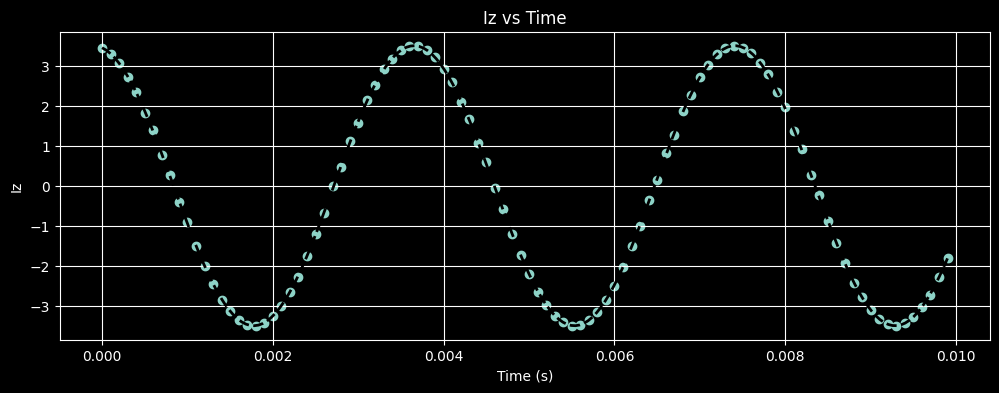

0.0037560173952374274

In [6]:
# Iz vs time (kicks)

data = LoadMewtwoData(SimPath + r'/sim_results/DynamicalTunnelingSimulation20251202172224')
ds = data.__dict__
Iz_array = ds['meas_marker'].__dict__['Iz'].__dict__['rhoI1']
kick_dt = 1e-4  # seconds per kick from       "pulse_width" in gate_config.json

n_kicks = np.arange(len(Iz_array))
time_s = n_kicks * kick_dt   # convert kicks → seconds
fit = SineFit(xvals=time_s, ydata=Iz_array)

plt.figure(figsize=(12,4))

# Plot raw data
plt.scatter(time_s, Iz_array, marker='o', label='Iz data')

# Plot fit
fit.add_to_plot(plt, label='Sine fit')

plt.xlabel('Time (s)')
plt.ylabel('Iz')
plt.title('Iz vs Time')
plt.grid(True)
plt.show()

two_pi_time = 1/fit.fit_result.params['frequency'].value
two_pi_time

In [7]:
Jz22=np.array([ [0.540062,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000],
                [0.000000,0.077152,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000],
                [0.000000,0.000000,-0.231455,0.000000,0.000000,0.000000,0.000000,0.000000],
                [0.000000,0.000000,0.000000,-0.385758,0.000000,0.000000,0.000000,0.000000],
                [0.000000,0.000000,0.000000,0.000000,-0.385758,0.000000,0.000000,0.000000],
                [0.000000,0.000000,0.000000,0.000000,0.000000,-0.231455,0.000000,0.000000],
                [0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.077152,0.000000],
                [0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.540062]])


## Dynamical tunneling

In [8]:
# Original glb 2pi time 1.875e-3

In [9]:
data = LoadMewtwoData(SimPath + r'/sim_results/DynamicalTunnelingSimulation20251204155503') 
ds = data.__dict__
n_kick = ds['rho_marker'].__dict__['Iz'].__dict__['rhoI1'].shape[2]
def show_frame(kick):
    plt.close('all')
    wigner_plot_hammer(Qobj(ds['rho_marker'].__dict__['Iz'].__dict__['rhoI1'][:,:,kick]), prob_function='husimi')
    plt.show()
interact(show_frame, kick=IntSlider(min=0, max=n_kick-1, step=1, value=0, layout={'width': '800px'}))

interactive(children=(IntSlider(value=0, description='kick', layout=Layout(width='800px'), max=19), Output()),…

<function __main__.show_frame(kick)>

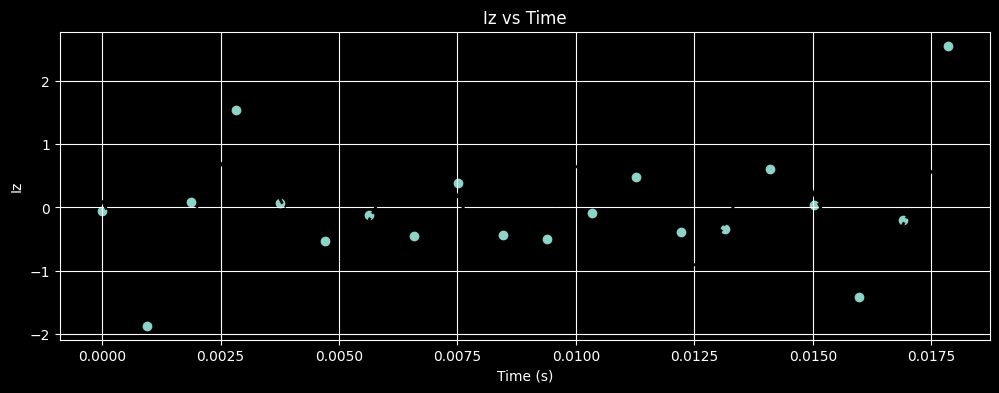

0.0037720543284541254

In [10]:
# Iz vs time (kicks)

Iz_array = ds['meas_marker'].__dict__['Iz'].__dict__['rhoI1']
kick_dt = 0.000939  # seconds per kick from       "pulse_width": in gate_config.json

n_kicks = np.arange(len(Iz_array))
time_s = n_kicks * kick_dt   # convert kicks → seconds
fit = SineFit(xvals=time_s, ydata=Iz_array)

plt.figure(figsize=(12,4))

# Plot raw data
plt.scatter(time_s, Iz_array, marker='o', label='Iz data')

# Plot fit
fit.add_to_plot(plt, label='Sine fit')

plt.xlabel('Time (s)')
plt.ylabel('Iz')
plt.title('Iz vs Time')
plt.grid(True)
plt.show()

two_pi_time = 1/fit.fit_result.params['frequency'].value
two_pi_time

In [11]:
# [X-P($K*A/7,T)-M]^20

## Dynamical Tunneling with noise

In [12]:
data = LoadMewtwoData(SimPath + r'/sim_results/DynamicalTunnelingSimulation20251203173354') # with noise, WhiteNoise_amp_7_alpha_0_samp_1us
ds = data.__dict__
# ds['gate_config'].__dict__['gate_defs'][0]
rho_kappas = ds['rho_marker'].__dict__['Iz'].__dict__['rhoI1']
print(rho_kappas.shape[0], 'kappa values')

my_kappa_index = 3
n_kick = rho_kappas[my_kappa_index].shape[2]
def show_frame(kick):
    plt.close('all')
    wigner_plot_hammer(Qobj(rho_kappas[my_kappa_index][:,:,kick]), prob_function='husimi')
    plt.show()
interact(show_frame, kick=IntSlider(min=0, max=n_kick-1, step=1, value=0, layout={'width': '800px'}))

4 kappa values


interactive(children=(IntSlider(value=0, description='kick', layout=Layout(width='800px'), max=11), Output()),…

<function __main__.show_frame(kick)>

## Dynamical Tunneling while off resonance

In [13]:
data = LoadMewtwoData(SimPath + r'/sim_results/DynamicalTunnelingSimulation20251204171858') 
ds = data.__dict__
n_kick = ds['rho_marker'].__dict__['Iz'].__dict__['rhoI1'].shape[2]
def show_frame(kick):
    plt.close('all')
    wigner_plot_hammer(Qobj(ds['rho_marker'].__dict__['Iz'].__dict__['rhoI1'][:,:,kick]), prob_function='husimi')
    plt.show()
interact(show_frame, kick=IntSlider(min=0, max=n_kick-1, step=1, value=0, layout={'width': '800px'}))

interactive(children=(IntSlider(value=0, description='kick', layout=Layout(width='800px'), max=19), Output()),…

<function __main__.show_frame(kick)>